In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_graphviz

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier

sns.set_style('darkgrid') 

GLOBAL_SEED = 42

In [ ]:
# @title Installing SHAP
import lightgbm as lgb
try:
  import lightgbm
except:
  print("Installing lightgbm")
  !pip install lightgbm
    
import lightgbm as lgb 

In [3]:
# import graphviz

In [2]:
# @title Installing SHAP
try:
  import shap
except:
  print("Installing SHAP")
  !pip install shap
    
import shap    

In [3]:
pwd

'/Users/tanviralam/QF/Research/Conferece_WorkingVersion/2026/GallStone_ICHSM'

In [9]:
fName='GallStone_dataset-uci.csv'
df = pd.read_csv(fName) 
print(df.shape)



(319, 39)


In [10]:

df["Gallstone Status"]  = df["Gallstone Status"].replace({"Case":1, "Control":0})
y = df["Gallstone Status"]
X = df.drop(["Gallstone Status"], axis=1)




In [11]:
print(y.head(-5))
#sns.pairplot(X)
# sns.pairplot(df,hue="Gallstone Status" )

0      0
1      0
2      0
3      0
4      0
      ..
309    1
310    1
311    1
312    1
313    1
Name: Gallstone Status, Length: 314, dtype: int64


In [13]:
GLOBAL_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=GLOBAL_SEED, shuffle=True)




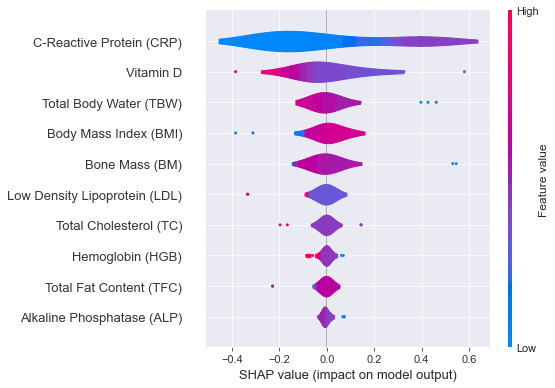

                    col_name  feature_importance_vals
35  C-Reactive Protein (CRP)                 7.310442
37                 Vitamin D                 3.838738
10    Total Body Water (TBW)                 1.921812
9      Body Mass Index (BMI)                 1.792427
18            Bone Mass (BM)                 1.619272



In [28]:
model = DecisionTreeClassifier(random_state=GLOBAL_SEED, min_samples_split=2)
model.fit(X_train, y_train)

topValueDisplay=10
# Initialize JavaScript visualizations in notebook environment
shap.initjs()
# Define a tree explainer for the built model
explainer = shap.TreeExplainer(model)
# obtain shap values for the first row of the test data
#shap_values = explainer.shap_values(X_test.iloc[0])
# obtain shap values for the test data
shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values[1], X_test, plot_type='bar', max_display=topValueDisplay)
# shap.summary_plot(shap_values[1], X_test)
shap.summary_plot(shap_values[1], X_test, plot_type='violin', max_display=topValueDisplay)
feature_names = X_test.columns
vals= np.abs(shap_values).mean(0)
feature_importance = pd.DataFrame(list(zip(feature_names, sum(vals))), columns=['col_name','feature_importance_vals'])
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False,inplace=True)
print(feature_importance.head())
print()
print("==================================================")

In [24]:
shap_values[1]

array([[ 0.        , -0.00242429,  0.        , ...,  0.39013342,
         0.03026589,  0.15788133],
       [ 0.        , -0.00217287,  0.        , ...,  0.01541791,
        -0.00307362, -0.04777382],
       [ 0.        , -0.00421149,  0.        , ..., -0.26698685,
        -0.01655839, -0.16574166],
       ...,
       [ 0.        , -0.00185913,  0.        , ...,  0.47536742,
         0.00143936, -0.00997842],
       [ 0.        ,  0.01472257,  0.        , ..., -0.05868149,
        -0.00099808, -0.04781113],
       [ 0.        , -0.00098321,  0.        , ..., -0.14719885,
         0.0699011 , -0.09375323]])

In [40]:
# shap.plots.bar(shap_values, max_display=99, show=False)
# plt.gcf()
# plt.savefig("bar.png")
# explainer = shap.Explainer(model)
# shap_values = explainer(X)
# shap.plots.bar(shap_values, max_display=99, show=False)
# plt.gcf()
# plt.savefig("barDT.png")

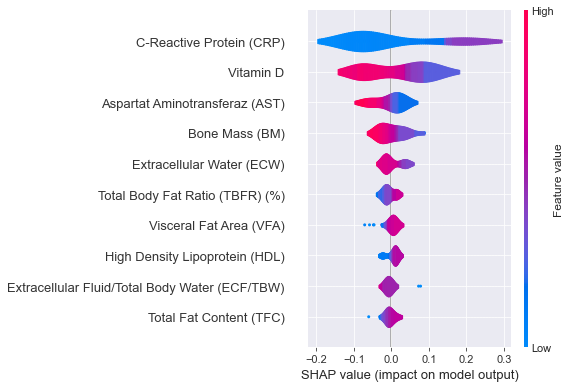

                                          col_name  feature_importance_vals
35                        C-Reactive Protein (CRP)                 3.403392
37                                       Vitamin D                 2.481807
30                  Aspartat Aminotransferaz (AST)                 0.987314
18                                  Bone Mass (BM)                 0.945219
11                       Extracellular Water (ECW)                 0.695038
14                 Total Body Fat Ratio (TBFR) (%)                 0.497295
22                         Visceral Fat Area (VFA)                 0.446977
28                  High Density Lipoprotein (HDL)                 0.432306
13  Extracellular Fluid/Total Body Water (ECF/TBW)                 0.415488
21                         Total Fat Content (TFC)                 0.410607



In [30]:
model = RandomForestClassifier(n_estimators=100) 
#LogisticRegression(random_state=0)
model.fit(X_train, y_train)

topValueDisplay=10
# Initialize JavaScript visualizations in notebook environment
shap.initjs()
# Define a tree explainer for the built model
explainer = shap.TreeExplainer(model)
# obtain shap values for the first row of the test data
#shap_values = explainer.shap_values(X_test.iloc[0])
# obtain shap values for the test data
shap_values = explainer.shap_values(X_test)
#shap.summary_plot(shap_values[1], X_test, plot_type='bar', max_display=topValueDisplay)
# shap.summary_plot(shap_values[1], X_test)
shap.summary_plot(shap_values[1], X_test, plot_type='violin', max_display=topValueDisplay)
feature_names = X_test.columns
vals= np.abs(shap_values).mean(0)
feature_importance = pd.DataFrame(list(zip(feature_names, sum(vals))), columns=['col_name','feature_importance_vals'])
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False,inplace=True)
print(feature_importance.head(topVarToShow))
print()
print("==================================================")